# Visualización Espacial — Shenzhen EV Charging
Integra `SZ_districts.shp` con los datasets del proyecto ChatEV.

In [9]:
%%capture
%pip install folium contextily

In [10]:
# Instalar dependencias si no están disponibles
import subprocess, sys
for pkg in ['geopandas', 'contextily', 'folium', 'mapclassify', 'osmnx']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

In [11]:
import os, subprocess
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from pathlib import Path

# ── Detectar entorno ──────────────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

BASE = None

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # Buscar stations.csv en Drive automáticamente
    result = subprocess.run(
        ['find', '/content/drive', '-name', 'stations.csv', '-not', '-path', '*/Trash/*'],
        capture_output=True, text=True, timeout=30
    )
    found = [p.strip() for p in result.stdout.strip().split('\n') if p.strip()]

    if found:
        # Usar el primero encontrado
        BASE = Path(found[0]).parent
        print(f'stations.csv encontrado en: {BASE}')
        if len(found) > 1:
            print(f'  (otros encontrados: {found[1:]})')
    else:
        raise FileNotFoundError(
            'stations.csv no encontrado en Drive.\n'
            'Asegúrate de que la carpeta datasets/ está correctamente subida a Drive.'
        )
else:
    BASE = Path('datasets')
    print(f'Entorno local. BASE: {BASE}')

SHP = BASE / 'SZ_districts' / 'SZ_districts.shp'
print(f'Entorno: {"Colab" if IN_COLAB else "Local"} | SHP existe: {SHP.exists()}')

# ── Cargar distritos ──────────────────────────────────────────────────────────
if SHP.exists():
    districts = gpd.read_file(SHP).to_crs('EPSG:4326')
    print('Shapefile cargado desde disco.')
else:
    print('Descargando 10 distritos de Shenzhen desde OSM...')
    import osmnx as ox
    SZ_DISTRICT_IDS = [5664191, 5664194, 5664195, 5663273, 5664101,
                       5664102, 5664193, 4590423, 5664192, 3536166]
    gdfs = []
    for rid in SZ_DISTRICT_IDS:
        g = ox.geocode_to_gdf(f'R{rid}', by_osmid=True)
        gdfs.append(g[['name', 'geometry']])
        print(f'  OK: {g["name"].iloc[0]}')
    districts = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs='EPSG:4326')
    SHP.parent.mkdir(parents=True, exist_ok=True)
    districts.to_crs('EPSG:3857').to_file(SHP, driver='ESRI Shapefile')
    print(f'Guardado en {SHP}')

# ── Cargar CSVs ───────────────────────────────────────────────────────────────
stations  = pd.read_csv(BASE / 'stations.csv')
info      = pd.read_csv(BASE / 'information.csv')
occupancy = pd.read_csv(BASE / 'occupancy.csv', index_col='timestamp')
volume    = pd.read_csv(BASE / 'volume.csv',    index_col='timestamp')

gdf_stations = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations.longitude, stations.latitude),
    crs='EPSG:4326'
)

print(f'\nDistritos:  {len(districts)}')
print(f'Estaciones: {len(stations)}')
print(f'Celdas grid:{len(info)}')
print(f'Timesteps:  {len(occupancy)}')
districts[['name']].head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
stations.csv encontrado en: /content/drive/MyDrive/datasets
Entorno: Colab | SHP existe: True
Shapefile cargado desde disco.

Distritos:  10
Estaciones: 1706
Celdas grid:247
Timesteps:  8640


,name
0,Futian District
1,Luohu District
2,Nanshan District
3,Yantian District
4,Bao'an District
5,Longgang District
6,Longhua District
7,Pingshan District
8,Guangming District
9,Dapeng New District


## 1. Mapa base — Distritos + Estaciones

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1891: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1891: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


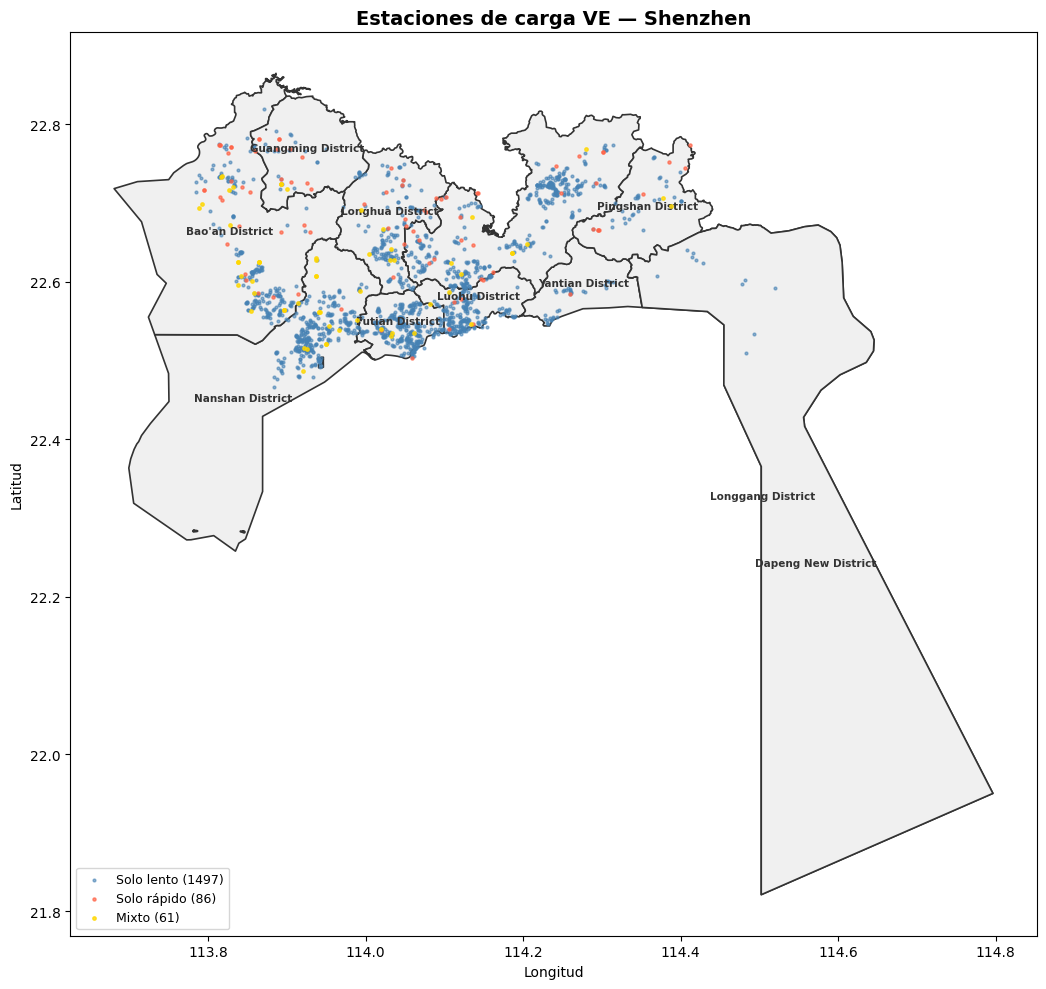

In [12]:
fig, ax = plt.subplots(figsize=(14, 10))

districts.plot(ax=ax, color='#f0f0f0', edgecolor='#333333', linewidth=1.2, zorder=1)

# Estaciones coloreadas por tipo (fast/slow/mixed)
fast_only  = gdf_stations[gdf_stations.fast > 0][gdf_stations.slow == 0]
slow_only  = gdf_stations[gdf_stations.slow > 0][gdf_stations.fast == 0]
mixed      = gdf_stations[(gdf_stations.fast > 0) & (gdf_stations.slow > 0)]

slow_only.plot(ax=ax, color='steelblue',  markersize=4, alpha=0.6, label=f'Solo lento ({len(slow_only)})',  zorder=2)
fast_only.plot(ax=ax, color='tomato',     markersize=5, alpha=0.7, label=f'Solo rápido ({len(fast_only)})', zorder=3)
mixed.plot(    ax=ax, color='gold',        markersize=6, alpha=0.8, label=f'Mixto ({len(mixed)})',           zorder=4)

# Etiquetas de distritos
for _, row in districts.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax.annotate(row['name'], (cx, cy), fontsize=7.5, ha='center',
                color='#333333', fontweight='bold')

ax.legend(loc='lower left', fontsize=9)
ax.set_title('Estaciones de carga VE — Shenzhen', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('map_stations.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Choropleth — Densidad de estaciones por distrito

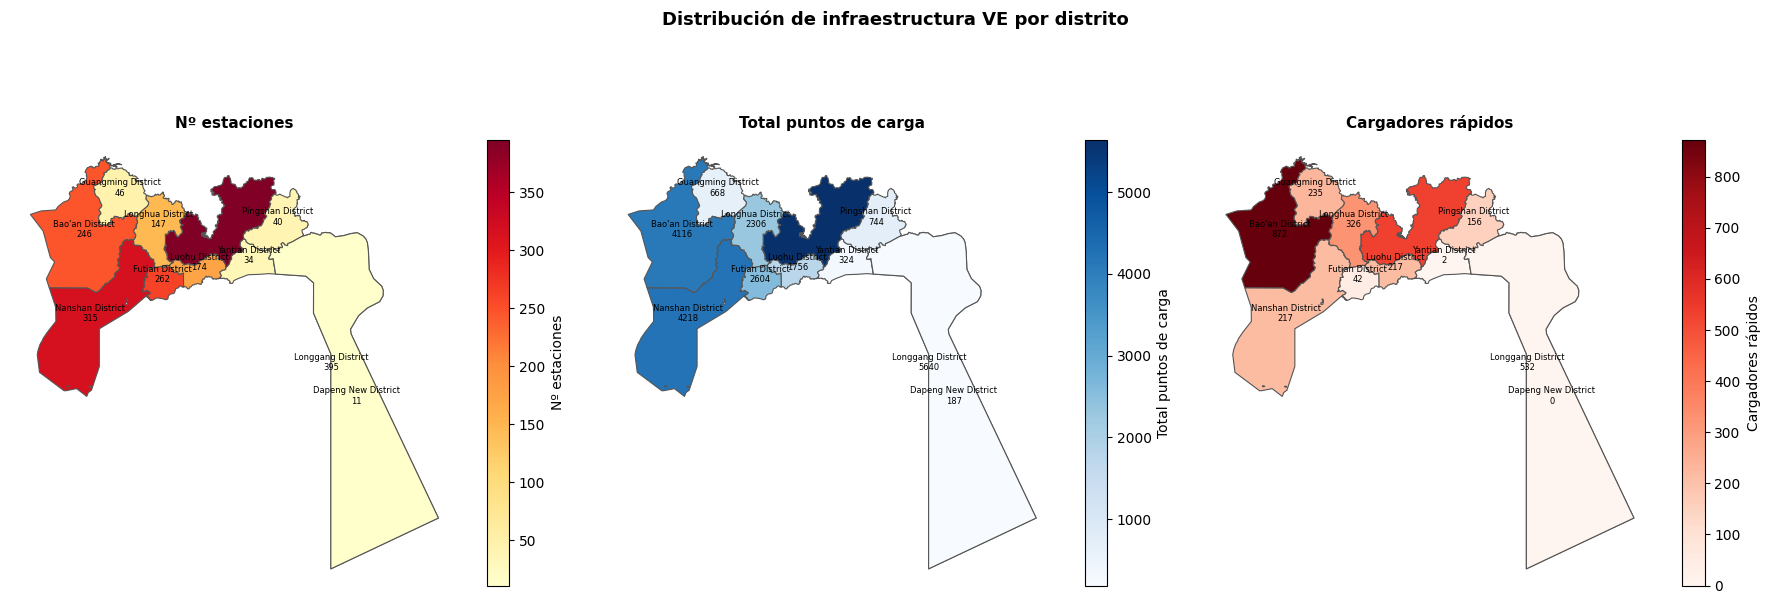

               name  n_stations  n_fast  n_slow  total_puntos
  Longgang District         395     532    5108          5640
   Nanshan District         315     217    4001          4218
    Futian District         262      42    2562          2604
    Bao'an District         246     872    3244          4116
     Luohu District         174     217    1539          1756
   Longhua District         147     326    1980          2306
 Guangming District          46     235     433           668
  Pingshan District          40     156     588           744
   Yantian District          34       2     322           324
Dapeng New District          11       0     187           187


In [13]:
# Spatial join: asignar cada estación a su distrito
joined = gpd.sjoin(gdf_stations, districts[['name', 'geometry']], how='left', predicate='within')
station_count = joined.groupby('name').agg(
    n_stations=('station_id', 'count'),
    n_fast=('fast', 'sum'),
    n_slow=('slow', 'sum'),
    total_puntos=('count', 'sum')
).reset_index()

districts_plot = districts.merge(station_count, on='name', how='left').fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

metrics = [
    ('n_stations',   'Nº estaciones',       'YlOrRd'),
    ('total_puntos', 'Total puntos de carga','Blues'),
    ('n_fast',       'Cargadores rápidos',   'Reds'),
]

for ax, (col, title, cmap) in zip(axes, metrics):
    districts_plot.plot(column=col, ax=ax, cmap=cmap, legend=True,
                        edgecolor='#555', linewidth=0.8,
                        legend_kwds={'shrink': 0.7, 'label': title})
    for _, row in districts_plot.iterrows():
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        ax.annotate(f"{row['name']}\n{int(row[col])}", (cx, cy),
                    fontsize=6, ha='center', color='black')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_axis_off()

plt.suptitle('Distribución de infraestructura VE por distrito', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('choropleth_districts.png', dpi=150, bbox_inches='tight')
plt.show()

print(station_count.sort_values('n_stations', ascending=False).to_string(index=False))

## 3. Heatmap — Ocupación media por celda de grid

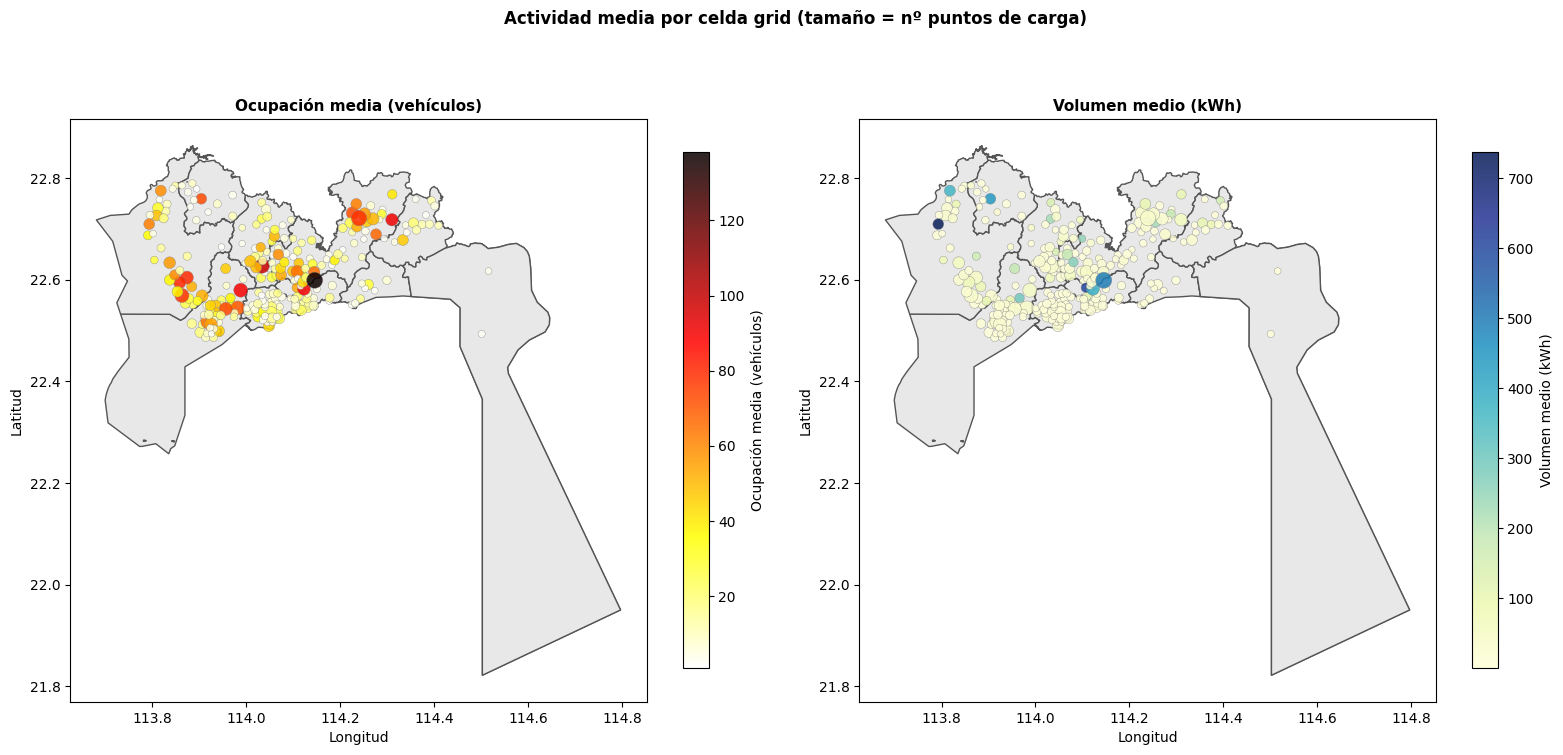

In [14]:
# Ocupación media temporal por grid
occ_mean = occupancy.mean(axis=0).reset_index()
occ_mean.columns = ['grid', 'occ_mean']
occ_mean['grid'] = occ_mean['grid'].astype(int)

vol_mean = volume.mean(axis=0).reset_index()
vol_mean.columns = ['grid', 'vol_mean']
vol_mean['grid'] = vol_mean['grid'].astype(int)

info_merged = info.merge(occ_mean, on='grid').merge(vol_mean, on='grid')
gdf_grid_stats = gpd.GeoDataFrame(
    info_merged,
    geometry=gpd.points_from_xy(info_merged.lon, info_merged.la),
    crs='EPSG:4326'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, (col, title, cmap) in zip(axes, [
    ('occ_mean', 'Ocupación media (vehículos)', 'hot_r'),
    ('vol_mean', 'Volumen medio (kWh)',          'YlGnBu'),
]):
    districts.plot(ax=ax, color='#e8e8e8', edgecolor='#555', linewidth=1, zorder=1)
    sc = ax.scatter(
        gdf_grid_stats.lon, gdf_grid_stats.la,
        c=gdf_grid_stats[col], cmap=cmap,
        s=gdf_grid_stats['count'] * 0.3 + 20,
        alpha=0.85, zorder=2,
        edgecolors='gray', linewidths=0.3
    )
    plt.colorbar(sc, ax=ax, shrink=0.7, label=title)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')

plt.suptitle('Actividad media por celda grid (tamaño = nº puntos de carga)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. CBD vs No-CBD — Comparación espacial

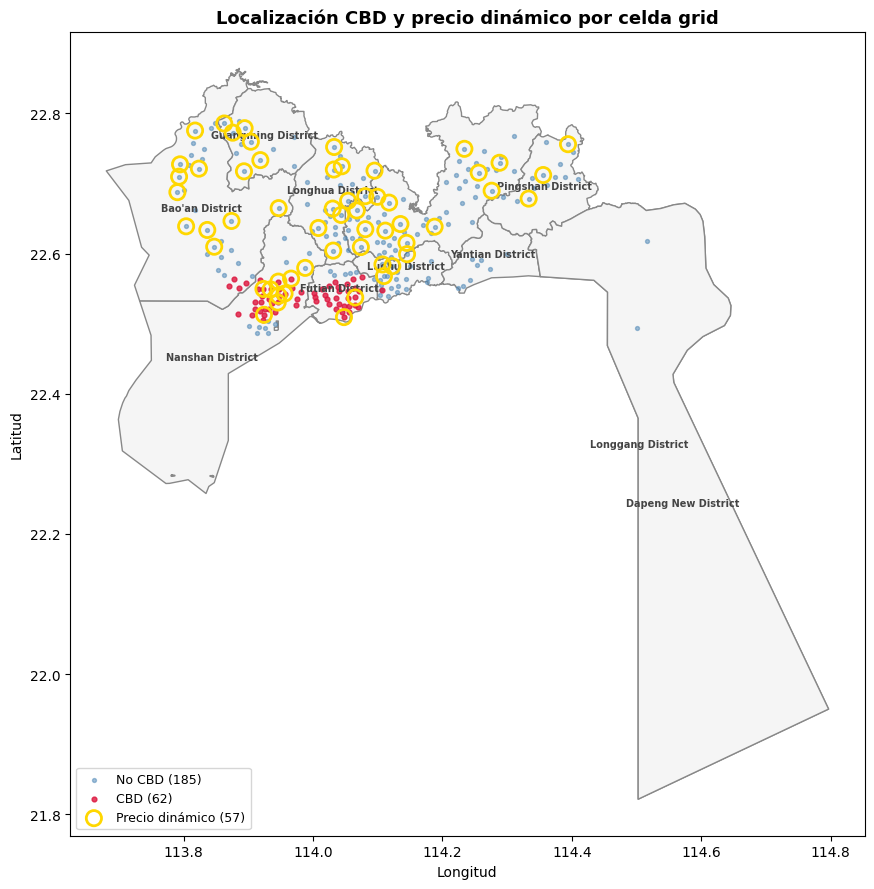

CBD: 62 celdas | No CBD: 185 | Precio dinámico: 57
Occ media CBD: 19.9 | No CBD: 22.6
Vol media CBD: 17.2 | No CBD: 43.2


In [15]:
cbd     = gdf_grid_stats[gdf_grid_stats.CBD == 1]
no_cbd  = gdf_grid_stats[gdf_grid_stats.CBD == 0]
dynamic = gdf_grid_stats[gdf_grid_stats.dynamic_pricing == 1]

fig, ax = plt.subplots(figsize=(13, 9))
districts.plot(ax=ax, color='#f5f5f5', edgecolor='#888', linewidth=1, zorder=1)

no_cbd.plot(ax=ax, color='steelblue', markersize=8,  alpha=0.5, label=f'No CBD ({len(no_cbd)})', zorder=2)
cbd.plot(   ax=ax, color='crimson',   markersize=12, alpha=0.8, label=f'CBD ({len(cbd)})',        zorder=3)

# Precio dinámico: solo borde dorado — usar scatter directamente
ax.scatter(
    dynamic.geometry.x, dynamic.geometry.y,
    s=120, facecolors='none', edgecolors='gold', linewidths=2,
    label=f'Precio dinámico ({len(dynamic)})', zorder=4
)

for _, row in districts.iterrows():
    ax.annotate(row['name'], (row.geometry.centroid.x, row.geometry.centroid.y),
                fontsize=7, ha='center', color='#444', fontweight='bold')

ax.legend(loc='lower left', fontsize=9)
ax.set_title('Localización CBD y precio dinámico por celda grid', fontsize=13, fontweight='bold')
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
plt.tight_layout()
plt.savefig('map_cbd.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'CBD: {len(cbd)} celdas | No CBD: {len(no_cbd)} | Precio dinámico: {len(dynamic)}')
print(f'Occ media CBD: {cbd.occ_mean.mean():.1f} | No CBD: {no_cbd.occ_mean.mean():.1f}')
print(f'Vol media CBD: {cbd.vol_mean.mean():.1f} | No CBD: {no_cbd.vol_mean.mean():.1f}')

## 5. Series temporales — Top grids por volumen

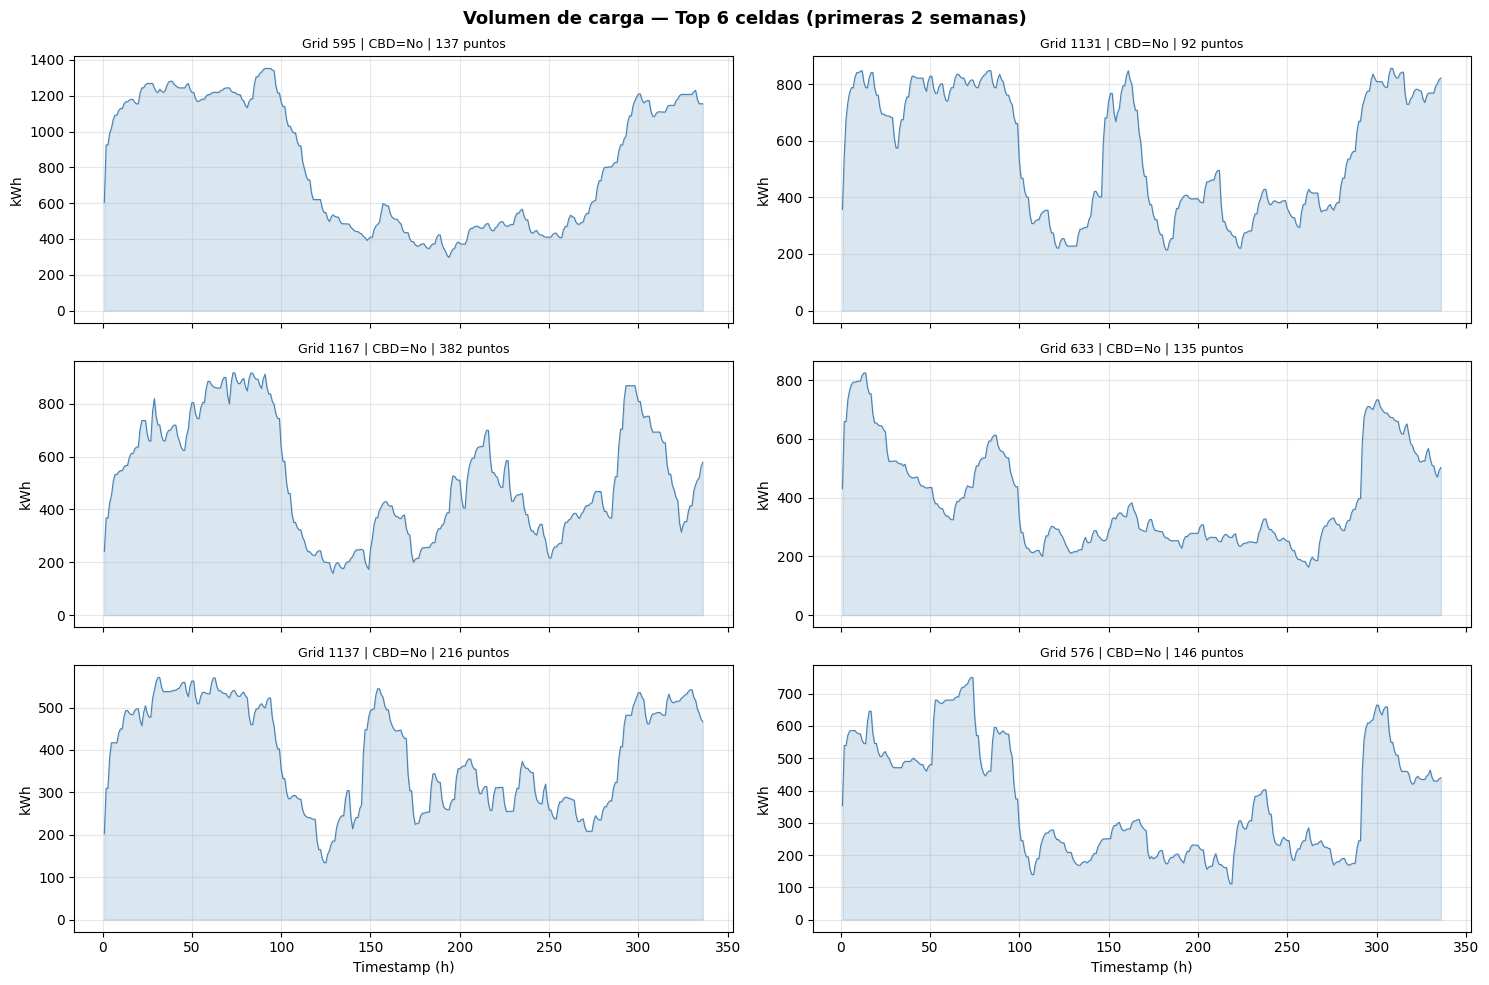

In [16]:
# Top 6 celdas por volumen medio
top6 = vol_mean.nlargest(6, 'vol_mean')['grid'].astype(str).tolist()

# Usar primeras 336 horas (2 semanas)
vol_subset = volume[top6].iloc[:336]

fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharex=True)

for ax, grid_id in zip(axes.flat, top6):
    grid_int = int(grid_id)
    row_info = info_merged[info_merged.grid == grid_int].iloc[0] if grid_int in info_merged.grid.values else None
    label = f"Grid {grid_id}"
    if row_info is not None:
        label += f" | CBD={'Sí' if row_info.CBD else 'No'} | {int(row_info['count'])} puntos"

    ax.plot(vol_subset.index, vol_subset[grid_id], color='steelblue', linewidth=0.8)
    ax.fill_between(vol_subset.index, vol_subset[grid_id], alpha=0.2, color='steelblue')
    ax.set_title(label, fontsize=9)
    ax.set_ylabel('kWh')
    ax.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel('Timestamp (h)')
axes[-1, 1].set_xlabel('Timestamp (h)')
plt.suptitle('Volumen de carga — Top 6 celdas (primeras 2 semanas)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('timeseries_top6.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Mapa interactivo — Folium

In [17]:
m = folium.Map(location=[22.65, 114.1], zoom_start=11, tiles='CartoDB positron')

# Distritos
folium.GeoJson(
    districts.__geo_interface__,
    style_function=lambda f: {
        'fillColor': '#e0e0e0', 'color': '#333333',
        'weight': 1.5, 'fillOpacity': 0.3
    },
    tooltip=folium.GeoJsonTooltip(fields=['name'], aliases=['Distrito:'])
).add_to(m)

# Estaciones (sample 500 para no saturar)
sample = gdf_stations.sample(min(500, len(gdf_stations)), random_state=42)
for _, row in sample.iterrows():
    color = 'red' if row.fast > 0 and row.slow == 0 else \
            'blue' if row.slow > 0 and row.fast == 0 else 'orange'
    folium.CircleMarker(
        location=[row.latitude, row.longitude],
        radius=4,
        color=color, fill=True, fill_opacity=0.7,
        popup=folium.Popup(
            f"ID: {int(row.station_id)}<br>Rápido: {int(row.fast)}<br>Lento: {int(row.slow)}",
            max_width=150
        )
    ).add_to(m)

# Leyenda
legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:9999;background:white;
            padding:10px;border:1px solid #ccc;border-radius:5px;font-size:12px">
  <b>Tipo cargador</b><br>
  <span style="color:red">●</span> Solo rápido<br>
  <span style="color:blue">●</span> Solo lento<br>
  <span style="color:orange">●</span> Mixto
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save('mapa_interactivo.html')
print('Guardado: mapa_interactivo.html')
m

Guardado: mapa_interactivo.html


## 7. Estadísticas resumen por distrito

                     n_grids  total_puntos  occ_media  vol_media  n_cbd  n_dynamic
name                                                                              
Luohu District            22          1800      23.09      79.92      1          4
Bao'an District           31          2978      32.88      67.76      4         10
Guangming District        12           442      10.57      43.73      0          6
Longgang District         58          4587      26.87      36.01      0         13
Longhua District          27          1762      20.99      35.94      0         10
Pingshan District         14           628      10.67      29.30      0          3
Nanshan District          39          3435      25.72      25.02     28          9
Futian District           35          2082      11.66       5.71     29          2
Yantian District           8           321       8.51       3.72      0          0
Dapeng New District        2            34       2.51       1.06      0          0


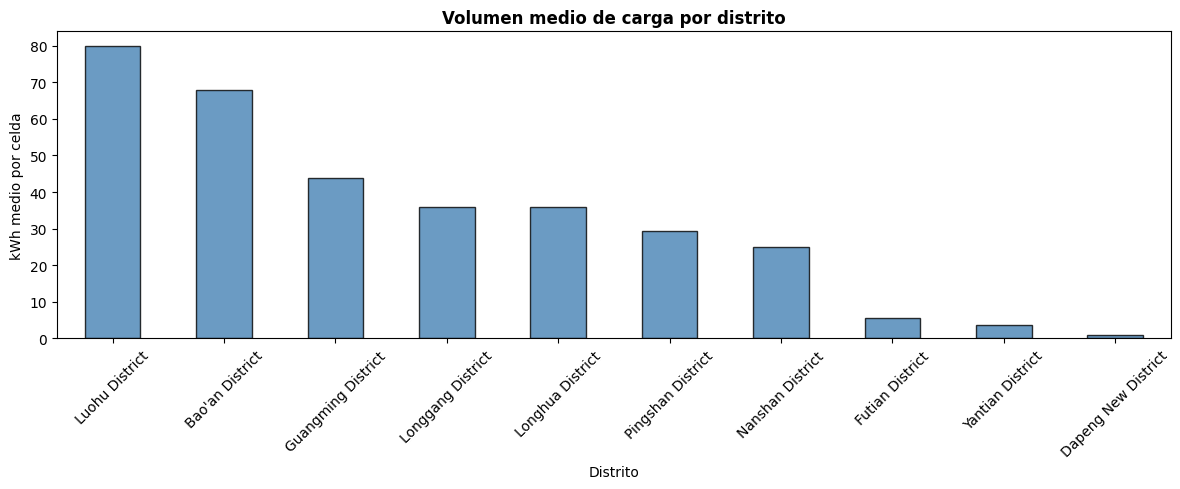

In [18]:
# Spatial join grid → distrito
grid_district = gpd.sjoin(gdf_grid_stats, districts[['name', 'geometry']], how='left', predicate='within')
summary = grid_district.groupby('name').agg(
    n_grids=('grid', 'count'),
    total_puntos=('count', 'sum'),
    occ_media=('occ_mean', 'mean'),
    vol_media=('vol_mean', 'mean'),
    n_cbd=('CBD', 'sum'),
    n_dynamic=('dynamic_pricing', 'sum')
).round(2).sort_values('vol_media', ascending=False)

print(summary.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
summary['vol_media'].plot(kind='bar', ax=ax, color='steelblue', alpha=0.8, edgecolor='black')
ax.set_title('Volumen medio de carga por distrito', fontsize=12, fontweight='bold')
ax.set_xlabel('Distrito')
ax.set_ylabel('kWh medio por celda')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('barplot_districts.png', dpi=150, bbox_inches='tight')
plt.show()